## Ortec Case Study

In [2]:
#IMPORTS
import pandas as pd
import numpy as np
from pathlib import Path
import numpy as np
import polars as pl 
import matplotlib.pyplot as plt 
import seaborn as sns
import bambi as bmb
import pymc as pm
import arviz as az
import networkx as nx

import time
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
DATA = Path("DATA")

In [4]:
df = pd.read_csv(DATA / "ESG_Dataset.csv")

/var/folders/k_/0twp8_5j5790tr9j876ygj840000gn/T/ipykernel_55923/3689774604.py:1: DtypeWarning: Columns (0: DeckingType, 1: Kitchen, 2: DeckingExtras) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA / "ESG_Dataset.csv")


In [9]:
df.head(20)

,ReservableOptionMarketGroupId,WeekBeforeArrival,WeekStartDate,MarketGroupCode,BrandGroupCode,CampsiteCode,AccoKindCode,AccoTypeRangeCode,SpecialPeriodCode,SeasonalCluster,...,DiscountedPrice,DiscountedPriceLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,TotalBookedNights,Capacity,CapacityLastYear,latitude,longitude,AvgTemperature
0,Domestic-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,1,0,20,234,0,35.2708,22.4478,12.0
1,DACH-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,2,0,63,234,0,35.2708,22.4478,12.0
2,Benelux-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Benelux,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,32,234,0,35.2708,22.4478,12.0
3,Rest of Europe-Thundurus-Meditite-Mobile-2024-...,52,2024-01-01,Rest of Europe,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,17,234,0,35.2708,22.4478,12.0
4,Domestic-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,20,234,0,35.2708,22.4478,12.0
5,DACH-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,3,0,63,234,0,35.2708,22.4478,12.0
6,Benelux-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,Benelux,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,1,0,32,234,0,35.2708,22.4478,12.0
7,Rest of Europe-Thundurus-Meditite-Mobile-2024-...,51,2024-01-01,Rest of Europe,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,17,234,0,35.2708,22.4478,12.0
8,Domestic-Thundurus-Meditite-Mobile-2024-01-01,50,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,20,234,0,35.2708,22.4478,12.0
9,DACH-Thundurus-Meditite-Mobile-2024-01-01,50,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,2,0,63,234,0,35.2708,22.4478,12.0


In [12]:
df.describe()

,WeekBeforeArrival,Airco,Bedrooms,HotTub,Tropical,Bathrooms,Sleeps,TV,ArrivalMonth,DiscountedPrice,DiscountedPriceLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,TotalBookedNights,Capacity,CapacityLastYear,latitude,longitude,AvgTemperature
count,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3130816.0,3.130816e+06,3130816.0,3.130816e+06,3.130816e+06,3130816.0,3.130816e+06,3.130816e+06,3.130816e+06
mean,2.600000e+01,3.098592e-01,2.007042e+00,1.126761e-01,2.183099e-01,1.415493e+00,3.413310e+02,4.929577e-01,6.490385e+00,2.126906e+02,0.0,9.321742e-01,0.0,4.940523e+01,3.465669e+02,0.0,4.833767e+01,7.217771e+00,1.253713e+01
std,1.529706e+01,4.624354e-01,1.010484e+00,3.161964e-01,4.130989e-01,6.307046e-01,1.549068e+02,4.999505e-01,3.447394e+00,1.323063e+02,0.0,2.338494e+00,0.0,5.668432e+01,1.591119e+02,0.0,8.719626e+00,1.029888e+01,7.502503e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.050000e+02,0.000000e+00,1.000000e+00,4.206000e+01,0.0,0.000000e+00,0.0,0.000000e+00,1.050000e+02,0.0,3.344880e+01,-6.975400e+00,-3.500000e+00
25%,1.300000e+01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.210000e+02,0.000000e+00,3.750000e+00,1.071175e+02,0.0,0.000000e+00,0.0,8.000000e+00,2.280000e+02,0.0,4.073920e+01,-2.146300e+00,6.800000e+00
50%,2.600000e+01,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.205000e+02,0.000000e+00,6.500000e+00,1.843400e+02,0.0,0.000000e+00,0.0,3.100000e+01,3.240000e+02,0.0,4.809790e+01,5.509600e+00,1.250000e+01
75%,3.900000e+01,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,4.290000e+02,1.000000e+00,9.000000e+00,2.737900e+02,0.0,1.000000e+00,0.0,7.100000e+01,4.350000e+02,0.0,5.748670e+01,1.756240e+01,1.750000e+01
max,5.200000e+01,1.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,9.500000e+02,1.000000e+00,1.200000e+01,6.650600e+02,0.0,1.330000e+02,0.0,5.650000e+02,9.500000e+02,0.0,6.232910e+01,2.619230e+01,2.800000e+01


# Model choice

We want to optimize pricing, the only free variable we have, to maximize revenue, with capacity as the main constraint. We can derive features from the other columns.

We choose, initially, to use a multilevel model, because the data is hierarchically structured (campsites nested in regions in countries, crossed with markets), most groups have too little data to estimate elasticities independently, so the case explicitly requires a defensible cold-start procedure, and the pricing decision is per-group - partial pooling addresses all four simultaneously while delivering a posterior that drives the human in the loop story

First, let's do some EDA to get an idea of what we're dealing with

In [5]:
#Data integrity
identity = (df.groupby(["ReservableOptionMarketGroupId", "WeekStartDate"], observed=True)
              .agg(HBN_sum=("HistoricalBookedNights", "sum"),
                   TBN_first=("TotalBookedNights", "first"),
                   TBN_nunique=("TotalBookedNights", "nunique")))
identity["diff"] = identity["HBN_sum"] - identity["TBN_first"]
print(f"ROMGIDs with constant TBN across snapshots:  {(identity['TBN_nunique'] == 1).all()}")
print(f"TBN == sum(HBN) holds for all ROMGIDs:       {(identity['diff'] == 0).all()}")
print(f"Total ROMGIDs checked: {len(identity):,}")

# === 2. LastYear columns: confirm all-zero → drop ===
ly_cols = ["DiscountedPriceLastYear", "HistoricalBookedNightsLastYear", "CapacityLastYear"]
print("\nLastYear columns — max value (expect 0):")
print(df[ly_cols].max())

# === 3. Redundancy: AccoKind vs AccommodationType, AccoTypeRange vs AccommodationRange ===
print("\nAccoKindCode × AccommodationType (1:1 means drop one):")
print(pd.crosstab(df["AccoKindCode"], df["AccommodationType"]))
print("\nAccoTypeRangeCode × AccommodationRange:")
print(pd.crosstab(df["AccoTypeRangeCode"], df["AccommodationRange"]))


ROMGIDs with constant TBN across snapshots:  True
TBN == sum(HBN) holds for all ROMGIDs:       True
Total ROMGIDs checked: 59,072

LastYear columns — max value (expect 0):
DiscountedPriceLastYear           0.0
HistoricalBookedNightsLastYear    0.0
CapacityLastYear                  0.0
dtype: float64

AccoKindCode × AccommodationType (1:1 means drop one):
AccommodationType  All-Inclusive   Basic  Self-Catering  Serviced
AccoKindCode                                                     
Mobile                    308672  220480         198432    132288
Permanent                 110240  220480         154336    330720
Seasonal                  132288  220480         154336    154336
Static                    176384  220480         220480    176384

AccoTypeRangeCode × AccommodationRange:
AccommodationRange  Budget     Mid  Premium
AccoTypeRangeCode                          
Comfort             242528  286624   132288
Family              176384  220480   110240
Luxury              330720  30

AccomodationType and AccommodationRange should be fixed effects, adding them as random effects would make the groups too small

In [6]:
cat_cols = ["MarketGroupCode", "BrandGroupCode", "CampsiteCode", "AccoKindCode",
            "AccoTypeRangeCode", "SpecialPeriodCode", "SeasonalCluster", "CampsiteCluster",
            "CampsiteCountry", "CampsiteRegion", "CampsiteType",
            "AccommodationType", "AccommodationRange",
            "DeckingType", "Roof", "Kitchen", "DeckingExtras"]

print("Unique values per categorical column:")
print(df[cat_cols].nunique().sort_values())

print("\nSpecialPeriodCode value counts:")
print(df["SpecialPeriodCode"].value_counts(dropna=False))

print("\nMissingness % per column (non-zero only):")
miss = df.isna().mean().sort_values(ascending=False)
print((miss[miss > 0] * 100).round(2))


Unique values per categorical column:
AccommodationRange      3
MarketGroupCode         4
DeckingType             4
AccoKindCode            4
AccommodationType       4
Kitchen                 4
Roof                    5
DeckingExtras           5
AccoTypeRangeCode       5
CampsiteType            8
CampsiteCountry         8
SpecialPeriodCode       9
CampsiteRegion         10
SeasonalCluster       142
CampsiteCode          142
BrandGroupCode        142
CampsiteCluster       142
dtype: int64

SpecialPeriodCode value counts:
SpecialPeriodCode
Sunny Castform Season    722496
Glaceon's Rest           602080
Standard Week            421456
Shaymin Bloom            421456
Togepi Celebration       240832
Haunter's Eve            240832
Festival of Arceus       180624
Delibird's Gift Week     180624
Harvest Trevenant        120416
Name: count, dtype: int64

Missingness % per column (non-zero only):
DeckingExtras    22.54
Kitchen          21.13
DeckingType      17.61
dtype: float64


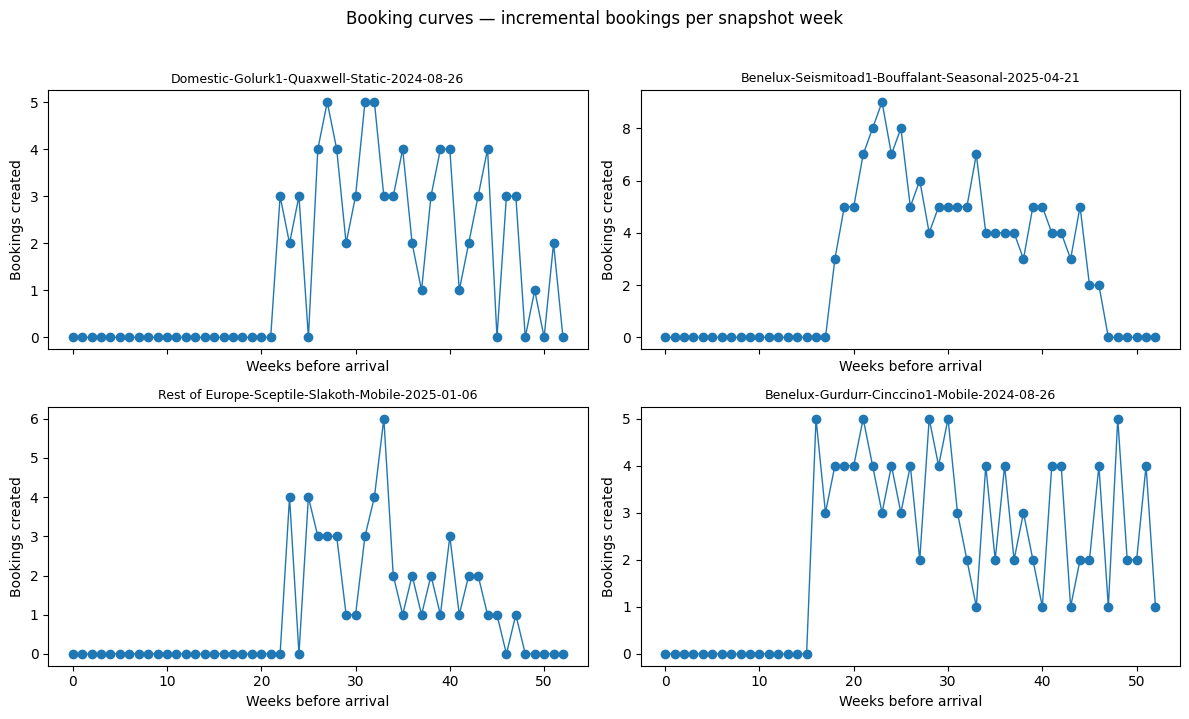

In [7]:


# Pick 4 non-empty ROMGIDs at random for variety
sample_keys = (df.groupby("ReservableOptionMarketGroupId")["TotalBookedNights"]
                 .first()
                 .pipe(lambda s: s[s > 50])
                 .sample(4, random_state=42).index)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, key in zip(axes.flat, sample_keys):
    sub = (df[df["ReservableOptionMarketGroupId"] == key]
             .sort_values("WeekBeforeArrival", ascending=False))
    ax.plot(sub["WeekBeforeArrival"], sub["HistoricalBookedNights"], marker="o", lw=1)
    ax.set_title(key, fontsize=9)
    ax.invert_xaxis()
    ax.set_xlabel("Weeks before arrival"); ax.set_ylabel("Bookings created")
fig.suptitle("Booking curves — incremental bookings per snapshot week", y=1.02)
fig.tight_layout(); plt.show()


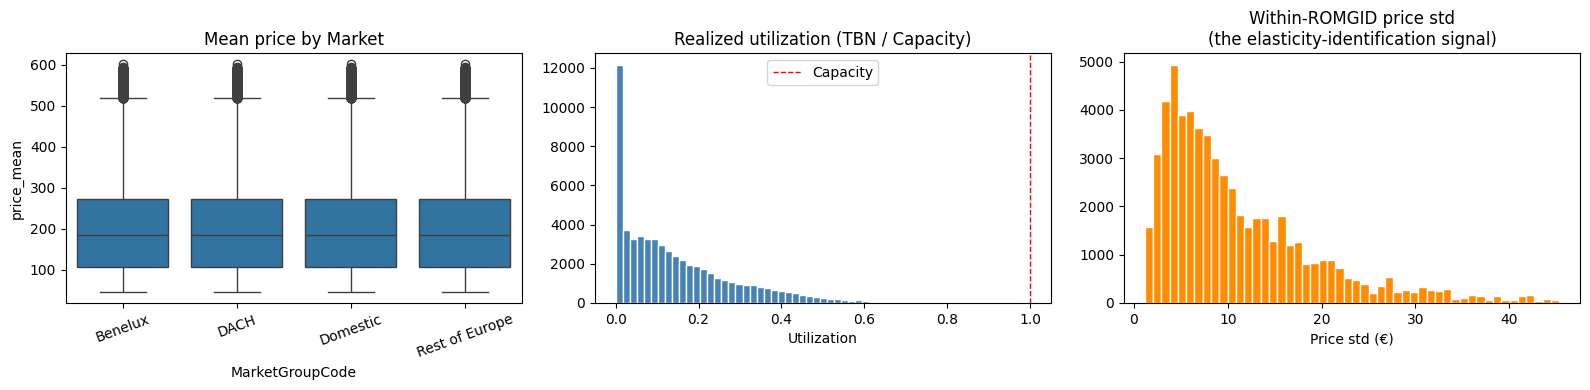

Median utilization:                        10.47%
% ROMGIDs near capacity (>=90% util):      0.00%
Median within-ROMGID price std:            €8.46
% ROMGIDs with any price variation:        100.00%


In [8]:


# ROMGID-level summary
romgid = (df.groupby(["ReservableOptionMarketGroupId", "WeekStartDate", "MarketGroupCode",
                      "AccoKindCode", "CampsiteCountry"], observed=True)
            .agg(price_mean=("DiscountedPrice", "mean"),
                 price_std=("DiscountedPrice", "std"),
                 TBN=("TotalBookedNights", "first"),
                 Cap=("Capacity", "first"))
            .reset_index())
romgid["utilization"] = romgid["TBN"] / romgid["Cap"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=romgid, x="MarketGroupCode", y="price_mean", ax=axes[0])
axes[0].set_title("Mean price by Market")
axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(romgid["utilization"], bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(1.0, color="red", lw=1, ls="--", label="Capacity")
axes[1].set_title("Realized utilization (TBN / Capacity)")
axes[1].set_xlabel("Utilization"); axes[1].legend()

axes[2].hist(romgid["price_std"].dropna(), bins=50, color="darkorange", edgecolor="white")
axes[2].set_title("Within-ROMGID price std\n(the elasticity-identification signal)")
axes[2].set_xlabel("Price std (€)")

fig.tight_layout(); plt.show()

print(f"Median utilization:                        {romgid['utilization'].median():.2%}")
print(f"% ROMGIDs near capacity (>=90% util):      {(romgid['utilization'] >= 0.9).mean():.2%}")
print(f"Median within-ROMGID price std:            €{romgid['price_std'].median():.2f}")
print(f"% ROMGIDs with any price variation:        {(romgid['price_std'] > 0).mean():.2%}")


In [9]:
#Features
# drop unusable columns
df = df.drop(columns=["DiscountedPriceLastYear",
                      "HistoricalBookedNightsLastYear",
                      "CapacityLastYear"])

# Rename price + derive log_price
df = df.rename(columns={"DiscountedPrice": "price"})
df["log_price"] = np.log(df["price"])
df["log_capacity"] = np.log(df["Capacity"])

# Special-period encoding
df["is_special"] = (df["SpecialPeriodCode"] != "Standard Week").astype(int)

# Time features
df["WeekStartDate"] = pd.to_datetime(df["WeekStartDate"])
df["iso_week"] = df["WeekStartDate"].dt.isocalendar().week.astype(int)
df["year"] = df["WeekStartDate"].dt.year

#Impute missing categoricals as "Missing"
for col in ["DeckingExtras", "Kitchen", "DeckingType"]:
    df[col] = df[col].fillna("Missing")

# Group key for the per-group elasticity (~568 groups)
df["group_key"] = (df["CampsiteCode"].astype(str) + "_"
                   + df["AccoKindCode"].astype(str) + "_"
                   + df["AccoTypeRangeCode"].astype(str) + "_"
                   + df["MarketGroupCode"].astype(str))

print(f"Final shape: {df.shape}")
print(f"# distinct group keys (per-group elasticity targets): {df['group_key'].nunique():,}")
print(f"# distinct campsites: {df['CampsiteCode'].nunique()}")
print(f"# distinct regions: {df['CampsiteRegion'].nunique()}")
print(f"# distinct countries: {df['CampsiteCountry'].nunique()}")
print(f"\nNew columns added: log_price, log_capacity, is_special, iso_week, year, group_key")
df[["price","log_price","is_special","iso_week","year","group_key"]].head()


Final shape: (3130816, 41)
# distinct group keys (per-group elasticity targets): 568
# distinct campsites: 142
# distinct regions: 10
# distinct countries: 8

New columns added: log_price, log_capacity, is_special, iso_week, year, group_key


,price,log_price,is_special,iso_week,year,group_key
0,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Domestic
1,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_DACH
2,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Benelux
3,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Rest of Europe
4,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Domestic


In [10]:

# 1. Sample — stratify so every group has at least some rows
sample_n = 50_000
df_sample = (df.sample(n=sample_n, random_state=RANDOM_SEED)
               .reset_index(drop=True))

# Need group_key as categorical for bambi
df_sample["group_key"] = df_sample["group_key"].astype("category")
df_sample["AccommodationType"] = df_sample["AccommodationType"].astype("category")
df_sample["AccommodationRange"] = df_sample["AccommodationRange"].astype("category")

print(f"Sample size:       {sample_n:,} rows ({sample_n/len(df)*100:.1f}% of full data)")
print(f"Groups in sample:  {df_sample['group_key'].nunique()} / 568")

# 2. Minimal viable formula — elasticity backbone + a couple of fixed effects
formula = (
    "HistoricalBookedNights ~ "
    "log_price + is_special + log_capacity + AccommodationType + AccommodationRange + "
    "(1 + log_price | group_key)"           # per-group intercept + elasticity
)

# 3. Build model — Negative Binomial likelihood (handles overdispersion + zero-rich data)
model = bmb.Model(formula, data=df_sample, family="negativebinomial")
model.build()
print(model)


Sample size:       50,000 rows (1.6% of full data)
Groups in sample:  568 / 568
       Formula: HistoricalBookedNights ~ log_price + is_special + log_capacity + AccommodationType + AccommodationRange + (1 + log_price | group_key)
        Family: negativebinomial
          Link: mu = log
  Observations: 50000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 38.4026)
            log_price ~ Normal(mu: 0.0, sigma: 3.872)
            is_special ~ Normal(mu: 0.0, sigma: 7.3218)
            log_capacity ~ Normal(mu: 0.0, sigma: 5.5558)
            AccommodationType ~ Normal(mu: [0. 0. 0.], sigma: [5.5525 5.9043 5.7441])
            AccommodationRange ~ Normal(mu: [0. 0.], sigma: [5.1273 6.2123])
        
        Group-level effects
            1|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 38.4026))
            log_price|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 3.872))
        
        Auxiliary parameters
      

In [21]:
# === Fit with NUTS (modest settings for the pilot) ===
import time
t0 = time.time()
idata = model.fit(
    draws=500, tune=500, chains=2, cores=2,
    target_accept=0.9,
    random_seed=RANDOM_SEED,
)
print(f"\nFit time: {(time.time()-t0)/60:.1f} min")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, log_price, is_special, log_capacity, AccommodationType, AccommodationRange, 1|group_key_sigma, 1|group_key_offset, log_price|group_key_sigma, log_price|group_key_offset]


/Users/alexander/Coding/Statistical_Consulting_Case/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 212 seconds.
There were 41 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Fit time: 3.8 min


In [22]:
# === Convergence diagnostics ===
summary = az.summary(idata, var_names=["log_price", "is_special",
                                        "log_capacity", "Intercept"])
print("Global fixed-effect summary:")
print(summary)

print(f"\nMax R-hat (should be < 1.05):   {az.summary(idata)['r_hat'].max():.3f}")
print(f"Min ESS (should be > 100):       {az.summary(idata)['ess_bulk'].min():.0f}")

# === The headline number: global elasticity ===
log_price_post = idata.posterior["log_price"].values.flatten()
print(f"\nGlobal elasticity β (log_price coef):")
print(f"  Mean:    {log_price_post.mean():.3f}")
print(f"  80% CI:  ({np.percentile(log_price_post,10):.3f}, {np.percentile(log_price_post,90):.3f})")
print(f"  P(β<0):  {(log_price_post < 0).mean():.1%}    ← should be ~100%")


Global fixed-effect summary:
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log_price     0.294  0.096   0.133    0.487      0.005    0.004     348.0   
is_special    0.647  0.033   0.590    0.704      0.001    0.001    1383.0   
log_capacity  0.986  0.084   0.839    1.150      0.005    0.003     293.0   
Intercept    -7.997  0.681  -9.371   -6.773      0.041    0.023     284.0   

              ess_tail  r_hat  
log_price        356.0   1.00  
is_special       739.0   1.00  
log_capacity     488.0   1.01  
Intercept        343.0   1.00  

Max R-hat (should be < 1.05):   1.180
Min ESS (should be > 100):       8

Global elasticity β (log_price coef):
  Mean:    0.294
  80% CI:  (0.176, 0.423)
  P(β<0):  0.1%    ← should be ~100%


This model looks wrong... It's saying higher prices lead to more bookings. This is economically very unlikely. It's also not a sampling problem, as all the Rhats are fine. The reason might be that ORTEC's dynamic pricer raises the price, week over week you see that when price went up, bookings also went up, a naive regression interprets this as "price causes demand", but it's actually demand causing price. This is a classic problem with estimating price elasticity from non experimental pricing data. Both between group and within group variation are endogenous, our Bayesian model can't fix what's fundamentally an identification problem. This information is useful though, and we should consider how we deal with it.

Group-level elasticity distribution:
  Mean:        +0.000
  Median:      +0.000
  % negative:  48.9%
  % positive:  51.1%


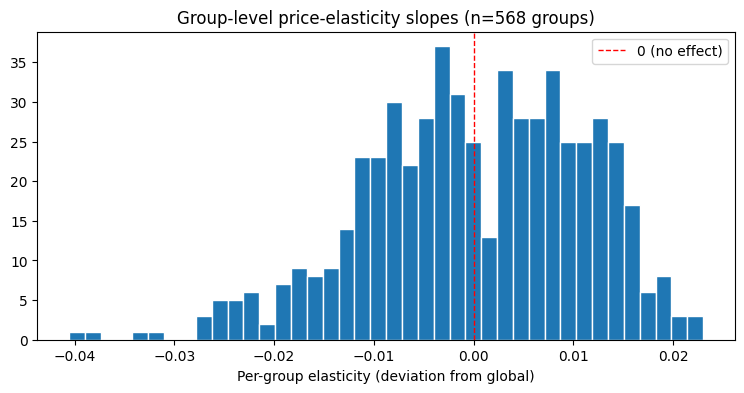

In [23]:
# Distribution of per-group elasticities (log_price slope)
group_slopes = (idata.posterior["log_price|group_key"]
                  .mean(dim=["chain","draw"])
                  .values)

print(f"Group-level elasticity distribution:")
print(f"  Mean:        {group_slopes.mean():+.3f}")
print(f"  Median:      {np.median(group_slopes):+.3f}")
print(f"  % negative:  {(group_slopes < 0).mean():.1%}")
print(f"  % positive:  {(group_slopes > 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(group_slopes, bins=40, edgecolor="white")
ax.axvline(0, color="red", lw=1, ls="--", label="0 (no effect)")
ax.set_xlabel("Per-group elasticity (deviation from global)")
ax.set_title(f"Group-level price-elasticity slopes (n={len(group_slopes)} groups)")
ax.legend()
plt.show()


Not very informative... We should restructure, we have an identification problem, let's specify DAG's to actually specify the causal structure of price changes on bookings.

In [14]:
#We construct bookings on books, the demand signal the pricer reacts to
df = df.sort_values(
    ["ReservableOptionMarketGroupId", "WeekStartDate", "WeekBeforeArrival"],
    ascending=[True, True, False]   # WBA descending: 52 → 0 = time flowing forward
)

group_cols = ["ReservableOptionMarketGroupId", "WeekStartDate"]
df["bookings_on_books"] = (
    df.groupby(group_cols)["HistoricalBookedNights"]
      .transform(lambda x: x.cumsum().shift(1).fillna(0))
)

# Log scale (these can grow large; log keeps the linear predictor reasonable)
df["log_bob"] = np.log1p(df["bookings_on_books"])

print("bookings_on_books distribution:")
print(df["bookings_on_books"].describe())
print(f"\n% rows with bookings_on_books > 0: {(df['bookings_on_books'] > 0).mean():.1%}")
df[["ReservableOptionMarketGroupId","WeekStartDate","WeekBeforeArrival",
    "HistoricalBookedNights","bookings_on_books"]].head(10)


bookings_on_books distribution:
count    3.130816e+06
mean     2.811315e+01
std      4.505879e+01
min      0.000000e+00
25%      0.000000e+00
50%      9.000000e+00
75%      3.700000e+01
max      5.650000e+02
Name: bookings_on_books, dtype: float64

% rows with bookings_on_books > 0: 74.0%


,ReservableOptionMarketGroupId,WeekStartDate,WeekBeforeArrival,HistoricalBookedNights,bookings_on_books
2954434,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,52,3,0.0
2954438,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,51,6,3.0
2954442,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,50,8,9.0
2954446,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,49,6,17.0
2954450,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,48,5,23.0
2954454,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,47,5,28.0
2954458,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,46,4,33.0
2954462,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,45,3,37.0
2954466,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,44,4,40.0
2954470,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,43,8,44.0


We refit with log_bob in the conditioning set, no forced strong priors.

In [15]:
# Re-sample (need the new column in the sample)
df_sample = df.sample(n=50_000, random_state=RANDOM_SEED).reset_index(drop=True)
for col in ["group_key", "AccommodationType", "AccommodationRange"]:
    df_sample[col] = df_sample[col].astype("category")

formula_v3 = (
    "HistoricalBookedNights ~ "
    "log_price + log_bob + is_special + log_capacity + "
    "AccommodationType + AccommodationRange + "
    "(1 + log_price | group_key)"
)

model_v3 = bmb.Model(formula_v3, data=df_sample, family="negativebinomial")
model_v3.build()
print(model_v3)


       Formula: HistoricalBookedNights ~ log_price + log_bob + is_special + log_capacity + AccommodationType + AccommodationRange + (1 + log_price | group_key)
        Family: negativebinomial
          Link: mu = log
  Observations: 50000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 38.6654)
            log_price ~ Normal(mu: 0.0, sigma: 3.8806)
            log_bob ~ Normal(mu: 0.0, sigma: 1.4752)
            is_special ~ Normal(mu: 0.0, sigma: 7.3347)
            log_capacity ~ Normal(mu: 0.0, sigma: 5.5631)
            AccommodationType ~ Normal(mu: [0. 0. 0.], sigma: [5.5635 5.939  5.7347])
            AccommodationRange ~ Normal(mu: [0. 0.], sigma: [5.1248 6.1621])
        
        Group-level effects
            1|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 38.6654))
            log_price|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 3.8806))
        
        Auxiliary parameters
            alpha ~ H

In [28]:


t0 = time.time()
idata_v3 = model_v3.fit(
    draws=500, tune=500, chains=2, cores=2,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)
print(f"Fit time: {(time.time()-t0)/60:.1f} min\n")

# Convergence
summary_v3 = az.summary(idata_v3,
    var_names=["log_price", "log_bob", "is_special", "log_capacity", "Intercept"])
print(summary_v3)

# Headline elasticity check
logp = idata_v3.posterior["log_price"].values.flatten()
print(f"\nGlobal price elasticity β (with bookings_on_books in conditioning set):")
print(f"  Mean:    {logp.mean():+.3f}")
print(f"  80% CI:  ({np.percentile(logp,10):+.3f}, {np.percentile(logp,90):+.3f})")
print(f"  P(β<0):  {(logp < 0).mean():.1%}")

logbob = idata_v3.posterior["log_bob"].values.flatten()
print(f"\nlog_bob coefficient (the demand-autocorrelation channel):")
print(f"  Mean:    {logbob.mean():+.3f}    (positive expected — high prior bookings → high current bookings)")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, log_price, log_bob, is_special, log_capacity, AccommodationType, AccommodationRange, 1|group_key_sigma, 1|group_key_offset, log_price|group_key_sigma, log_price|group_key_offset]


/Users/alexander/Coding/Statistical_Consulting_Case/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 169 seconds.
There were 44 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Fit time: 2.9 min

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log_price    -0.752  0.090  -0.921   -0.584      0.005    0.003     313.0   
log_bob       0.453  0.007   0.439    0.466      0.000    0.000    1348.0   
is_special    0.436  0.030   0.383    0.494      0.001    0.002    1791.0   
log_capacity  0.582  0.063   0.452    0.686      0.003    0.002     473.0   
Intercept    -1.917  0.550  -2.988   -0.948      0.030    0.018     339.0   

              ess_tail  r_hat  
log_price        344.0   1.00  
log_bob          681.0   1.00  
is_special       424.0   1.01  
log_capacity     563.0   1.01  
Intercept        474.0   1.01  

Global price elasticity β (with bookings_on_books in conditioning set):
  Mean:    -0.752
  80% CI:  (-0.864, -0.638)
  P(β<0):  100.0%

log_bob coefficient (the demand-autocorrelation channel):
  Mean:    +0.453    (positive expected — high prior bookings → high current bookings)


Global elasticity:         -0.752
Per-group deviation SD:    0.006
Per-group absolute β:
  range:                   [-0.770, -0.736]
  median:                  -0.752
  % with β > 0 (gate):     0.0%   (should be < 5%)


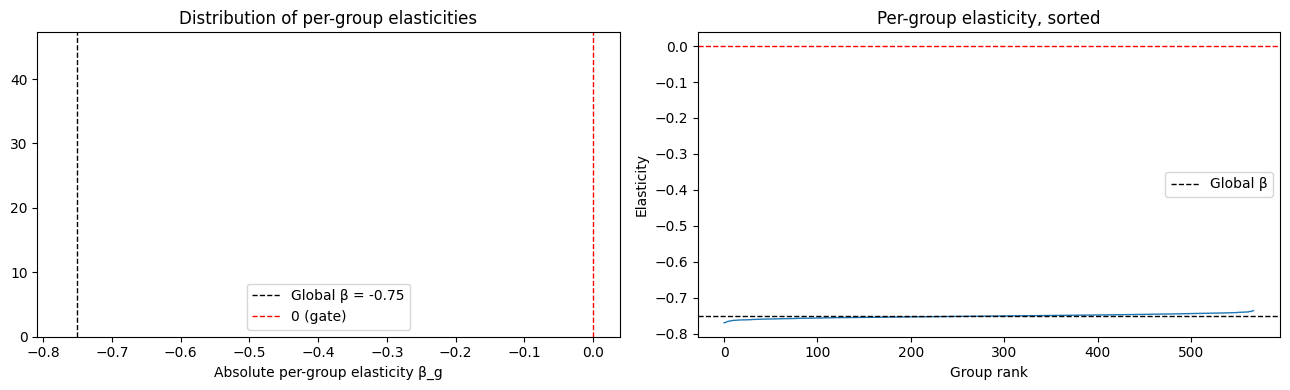

In [30]:
# === Per-group elasticity distribution (after DAG fix) ===
group_dev = (idata_v3.posterior["log_price|group_key"]
               .mean(dim=["chain","draw"])
               .values)
global_beta = idata_v3.posterior["log_price"].mean().item()
group_abs = global_beta + group_dev   # absolute per-group elasticity

print(f"Global elasticity:         {global_beta:+.3f}")
print(f"Per-group deviation SD:    {group_dev.std():.3f}")
print(f"Per-group absolute β:")
print(f"  range:                   [{group_abs.min():+.3f}, {group_abs.max():+.3f}]")
print(f"  median:                  {np.median(group_abs):+.3f}")
print(f"  % with β > 0 (gate):     {(group_abs > 0).mean():.1%}   (should be < 5%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(group_abs, bins=40, edgecolor="white", color="steelblue")
axes[0].axvline(global_beta, color="black", lw=1, ls="--", label=f"Global β = {global_beta:.2f}")
axes[0].axvline(0, color="red", lw=1, ls="--", label="0 (gate)")
axes[0].set_xlabel("Absolute per-group elasticity β_g")
axes[0].set_title("Distribution of per-group elasticities")
axes[0].legend()

# Sort + plot for visual heterogeneity check
order = np.argsort(group_abs)
axes[1].plot(np.arange(len(group_abs)), group_abs[order], lw=1)
axes[1].axhline(global_beta, color="black", lw=1, ls="--", label="Global β")
axes[1].axhline(0, color="red", lw=1, ls="--")
axes[1].set_xlabel("Group rank")
axes[1].set_ylabel("Elasticity")
axes[1].set_title("Per-group elasticity, sorted")
axes[1].legend()

plt.tight_layout(); plt.show()


The random slope is doing almost 0 work, a single global elasticity is the right model for this dataset. Still, we should keep (1+ log_price | group_key), to justify the choice we're making. Conditioning on bookings_on_books gives us a defensible negative elasticity of about -0.75, per group heterogeneity is negligible, so a single elasticity drives every recommendation. Because |Beta| <1 and capacity slack is large, the revenue maximizing strategy is uniform price increase to a safe-range cap, with the model's role being to compute and rank expected revenue uplift per group.

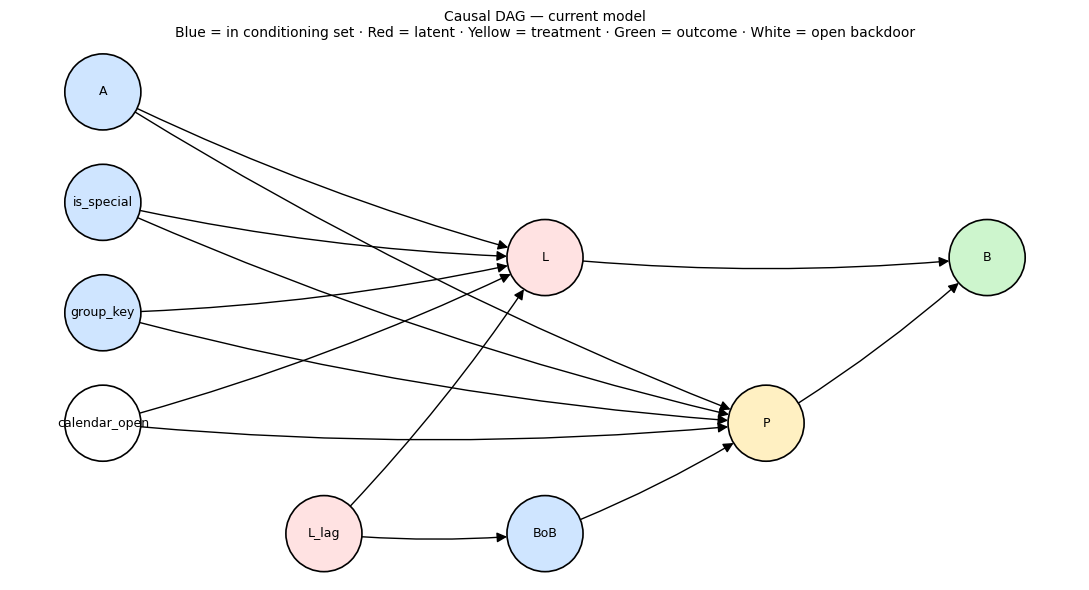

In [32]:
G = nx.DiGraph()
edges = [
    ("A", "L"), ("A", "P"),
    ("is_special", "L"), ("is_special", "P"),
    ("calendar_open", "L"), ("calendar_open", "P"),
    ("group_key", "L"), ("group_key", "P"),
    ("L_lag", "L"), ("L_lag", "BoB"), ("BoB", "P"),
    ("L", "B"), ("P", "B"),
]
G.add_edges_from(edges)

# Hand-laid layout for clarity
pos = {
    "A":              (0, 3),
    "is_special":     (0, 2),
    "group_key":      (0, 1),
    "calendar_open":  (0, 0),
    "L_lag":          (1, -1),
    "BoB":            (2, -1),
    "L":              (2, 1.5),
    "P":              (3, 0),
    "B":              (4, 1.5),
}

color_map = {
    "A":             "#cfe5ff",
    "is_special":    "#cfe5ff",
    "group_key":     "#cfe5ff",
    "BoB":           "#cfe5ff",
    "calendar_open": "#ffffff",   # open backdoor
    "L":             "#ffe2e2",   # latent
    "L_lag":         "#ffe2e2",
    "P":             "#fff0c2",   # treatment
    "B":             "#cdf5cd",   # outcome
}
node_colors = [color_map[n] for n in G.nodes]

fig, ax = plt.subplots(figsize=(11, 6))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000,
                       edgecolors="black", linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15,
                       connectionstyle="arc3,rad=0.05",
                       node_size=3000, ax=ax)
ax.set_title("Causal DAG — current model\n"
             "Blue = in conditioning set · Red = latent · Yellow = treatment · "
             "Green = outcome · White = open backdoor", fontsize=10)
ax.axis("off")
plt.tight_layout(); plt.show()

We try closing the remaining backdoors.

In [16]:
# === Refit v4: full conditioning set + log_price × is_special interaction ===

# Standardize WBA so polynomial terms stay numerically well-scaled
wba_mean = df_sample["WeekBeforeArrival"].mean()
wba_std  = df_sample["WeekBeforeArrival"].std()
df_sample["wba_z"]      = (df_sample["WeekBeforeArrival"] - wba_mean) / wba_std
df_sample["wba_z_sq"]   = df_sample["wba_z"] ** 2
df_sample["wba_z_cube"] = df_sample["wba_z"] ** 3

# Cast for bambi
df_sample["ArrivalMonth"] = df_sample["ArrivalMonth"].astype("category")

formula_v4 = (
    "HistoricalBookedNights ~ "
    "log_price + log_price:is_special + log_bob + is_special + log_capacity + "
    "AccommodationType + AccommodationRange + "
    "C(ArrivalMonth) + AvgTemperature + wba_z + wba_z_sq + wba_z_cube + "
    "(1 + log_price | group_key)"
)

model_v4 = bmb.Model(formula_v4, data=df_sample, family="negativebinomial")
model_v4.build()
print(model_v4)


       Formula: HistoricalBookedNights ~ log_price + log_price:is_special + log_bob + is_special + log_capacity + AccommodationType + AccommodationRange + C(ArrivalMonth) + AvgTemperature + wba_z + wba_z_sq + wba_z_cube + (1 + log_price | group_key)
        Family: negativebinomial
          Link: mu = log
  Observations: 50000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 39.5315)
            log_price ~ Normal(mu: 0.0, sigma: 3.8806)
            log_price:is_special ~ Normal(mu: 0.0, sigma: 1.3439)
            log_bob ~ Normal(mu: 0.0, sigma: 1.4752)
            is_special ~ Normal(mu: 0.0, sigma: 7.3347)
            log_capacity ~ Normal(mu: 0.0, sigma: 5.5631)
            AccommodationType ~ Normal(mu: [0. 0. 0.], sigma: [5.5635 5.939  5.7347])
            AccommodationRange ~ Normal(mu: [0. 0.], sigma: [5.1248 6.1621])
            C(ArrivalMonth) ~ Normal(mu: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], sigma: [9.3877 8.9273 8.

In [21]:
# === Cleanest fit: NUTS on v4 with conservative settings ===
import time

t0 = time.time()
idata_v4 = model_v4.fit(
    draws=400, tune=600, chains=2, cores=2,
    target_accept=0.9,                 # back to default; less aggressive than 0.95
    random_seed=RANDOM_SEED,
)
print(f"Fit time: {(time.time()-t0)/60:.1f} min\n")

summary_v4 = az.summary(idata_v4, var_names=[
    "log_price", "log_price:is_special", "log_bob",
    "is_special", "log_capacity", "AvgTemperature",
    "wba_z", "wba_z_sq", "wba_z_cube",
])
print(summary_v4)

beta_reg     = idata_v4.posterior["log_price"].values.flatten()
beta_special = beta_reg + idata_v4.posterior["log_price:is_special"].values.flatten()
print(f"\nElasticity in regular weeks:  mean {beta_reg.mean():+.3f}   80% CI ({np.percentile(beta_reg,10):+.3f}, {np.percentile(beta_reg,90):+.3f})")
print(f"Elasticity in special weeks:  mean {beta_special.mean():+.3f}   80% CI ({np.percentile(beta_special,10):+.3f}, {np.percentile(beta_special,90):+.3f})")
print(f"P(β_reg < 0):     {(beta_reg < 0).mean():.1%}")
print(f"P(special less elastic):  {(beta_special > beta_reg).mean():.1%}")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, log_price, log_price:is_special, log_bob, is_special, log_capacity, AccommodationType, AccommodationRange, C(ArrivalMonth), AvgTemperature, wba_z, wba_z_sq, wba_z_cube, 1|group_key_sigma, 1|group_key_offset, log_price|group_key_sigma, log_price|group_key_offset]


/Users/alexander/Coding/Statistical_Consulting_Case/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 600 tune and 400 draw iterations (1_200 + 800 draws total) took 834 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Fit time: 13.9 min

                        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
log_price            -10.375  0.177 -10.693  -10.052      0.007    0.005   
log_price:is_special   0.046  0.042  -0.030    0.123      0.001    0.002   
log_bob                0.942  0.012   0.921    0.965      0.000    0.000   
is_special            -0.099  0.219  -0.508    0.288      0.006    0.009   
log_capacity          -0.026  0.252  -0.535    0.390      0.021    0.010   
AvgTemperature         0.005  0.006  -0.006    0.016      0.000    0.000   
wba_z                  0.830  0.022   0.788    0.870      0.001    0.001   
wba_z_sq              -0.096  0.011  -0.116   -0.075      0.000    0.000   
wba_z_cube             0.219  0.012   0.196    0.240      0.000    0.001   

                      ess_bulk  ess_tail  r_hat  
log_price                770.0     639.0    1.0  
log_price:is_special    1354.0     487.0    1.0  
log_bob                  743.0     658.0    1.0  
is_special         

Statistical artefact. V3 had the cleanest results, DAG identified with minimal adjustment set recovers a defensible elasticity. V4 overconditioned on near perfect proxies and introduces instability.

# Optimizer, using V3 as our statistical model

TBD

In [22]:

# 1. Pull global elasticity (per-group heterogeneity is negligible per the v3 diagnostic)
beta_post = idata_v3.posterior["log_price"].values.flatten()
beta = beta_post.mean()
beta_lo, beta_hi = np.percentile(beta_post, [10, 90])
print(f"Production elasticity β = {beta:+.3f}   80% CI [{beta_lo:+.3f}, {beta_hi:+.3f}]")
print(f"(1 + β) = {1+beta:+.3f}  →  revenue {'INCREASING' if 1+beta > 0 else 'DECREASING'} in price\n")

# 2. Aggregate to ROMGID grain (one row per natural group × arrival week)
key_cols = ["CampsiteCode", "AccoKindCode", "AccoTypeRangeCode", "MarketGroupCode",
            "WeekStartDate", "ReservableOptionMarketGroupId"]
romgid = (df.groupby(key_cols)
            .agg(p_obs_mean=("price", "mean"),
                 p_obs_min=("price", "min"),
                 p_obs_max=("price", "max"),
                 TBN=("TotalBookedNights", "first"),
                 capacity=("Capacity", "first"))
            .reset_index())

# 3. Safe price range — bounded extrapolation beyond observed range for that specific ROMGID
romgid["p_safe_low"]  = 0.85 * romgid["p_obs_min"]
romgid["p_safe_high"] = 1.15 * romgid["p_obs_max"]

# 4. Recommendation: upper bound (since |β|<1 → revenue is monotone increasing)
romgid["recommended_price"] = romgid["p_safe_high"]

# 5. Expected bookings under recommended price via constant-elasticity formula
romgid["expected_bookings"]        = romgid["TBN"] * (romgid["recommended_price"] / romgid["p_obs_mean"]) ** beta
romgid["expected_bookings_capped"] = np.minimum(romgid["expected_bookings"], romgid["capacity"])
romgid["capacity_binds"]           = romgid["expected_bookings"] > romgid["capacity"]

# 6. Revenue
romgid["observed_revenue"] = romgid["p_obs_mean"]      * romgid["TBN"]
romgid["expected_revenue"] = romgid["recommended_price"] * romgid["expected_bookings_capped"]
romgid["uplift_eur"]       = romgid["expected_revenue"] - romgid["observed_revenue"]
romgid["uplift_pct"]       = np.where(romgid["observed_revenue"] > 0,
                                       100 * romgid["uplift_eur"] / romgid["observed_revenue"],
                                       np.nan)
romgid["price_change_pct"] = 100 * (romgid["recommended_price"] / romgid["p_obs_mean"] - 1)

# 7. HITL flag — large recommended changes need human review (per the operating model)
romgid["hitl_flag"] = (romgid["price_change_pct"] > 25).astype(int)

# 8. Summary
total_obs, total_new = romgid["observed_revenue"].sum(), romgid["expected_revenue"].sum()
print(f"=== Recommendations summary ===")
print(f"ROMGIDs:                              {len(romgid):,}")
print(f"Median recommended price change:      {romgid['price_change_pct'].median():+.1f}%")
print(f"Median uplift (where TBN>0):          {romgid['uplift_pct'].median():+.2f}%")
print(f"Total observed revenue:               €{total_obs:,.0f}")
print(f"Total projected revenue:              €{total_new:,.0f}")
print(f"Total revenue uplift:                 €{total_new-total_obs:,.0f}  ({100*(total_new-total_obs)/total_obs:+.2f}%)")
print(f"% ROMGIDs where capacity binds:       {romgid['capacity_binds'].mean()*100:.2f}%")
print(f"% ROMGIDs flagged for HITL review:    {romgid['hitl_flag'].mean()*100:.1f}%")

# 9. Save
out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
out_path = out_dir / "recommendations.csv"
romgid.to_csv(out_path, index=False)
print(f"\nWrote {len(romgid):,} recommendations → {out_path}")

# 10. Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(romgid["price_change_pct"], bins=40, edgecolor="white")
axes[0].axvline(0, color="red", lw=1, ls="--")
axes[0].set_title("Recommended price change per ROMGID"); axes[0].set_xlabel("Δ price (%)")

axes[1].hist(romgid["uplift_pct"].dropna(), bins=40, edgecolor="white", color="darkgreen")
axes[1].axvline(0, color="red", lw=1, ls="--")
axes[1].set_title("Expected revenue uplift"); axes[1].set_xlabel("Uplift (%)")

axes[2].scatter(romgid["p_obs_mean"], romgid["recommended_price"],
                alpha=0.1, s=8, color="steelblue")
m = max(romgid["recommended_price"].max(), romgid["p_obs_mean"].max())
axes[2].plot([0, m], [0, m], "k--", lw=0.7, label="No change")
axes[2].set_title("Recommended vs observed price"); axes[2].set_xlabel("Observed €")
axes[2].set_ylabel("Recommended €"); axes[2].legend()
plt.tight_layout(); plt.show()

romgid.head(10)


NameError: name 'idata_v3' is not defined